In [9]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
print("teste")

teste


In [11]:
import tensorflow as tf

In [12]:
dataset_folder = "dataset"

In [45]:
train_dataset = tf.keras.utils.image_dataset_from_directory( dataset_folder, validation_split=0.2, subset="training", seed=123, image_size=(128, 128), batch_size=32 )

Found 24998 files belonging to 2 classes.
Using 19999 files for training.


In [49]:
validation_dataset = tf.keras.utils.image_dataset_from_directory( dataset_folder, validation_split=0.2, subset="validation", seed=123, image_size=(128, 128), batch_size=32 )

Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [15]:
print(train_dataset.class_names)

['cats', 'dogs']


In [16]:
for images, labels in train_dataset.take(1):
    print("Formato das imagens:", images.shape)
    print("Rótulos:", labels.numpy())

Formato das imagens: (32, 128, 128, 3)
Rótulos: [1 1 1 1 1 1 1 1 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0]


In [17]:
print("Tipo dos pixels:", images.dtype)
print("Menor valor:", tf.reduce_min(images).numpy())
print("Maior valor:", tf.reduce_max(images).numpy())

Tipo dos pixels: <dtype: 'float32'>
Menor valor: 0.0
Maior valor: 255.0


In [48]:
normalized_images = images / 255.0

print("Menor valor:", tf.reduce_min(normalized_images).numpy())
print("Maior valor:", tf.reduce_max(normalized_images).numpy())

Menor valor: 0.0
Maior valor: 0.003921569


In [19]:
def normalize(images, labels):
    return images / 255.0, labels

train_dataset = train_dataset.map(normalize)
validation_dataset = validation_dataset.map(normalize)

In [20]:
for images, labels in train_dataset.take(1):
    print("Menor valor:", tf.reduce_min(images).numpy())
    print("Maior valor:", tf.reduce_max(images).numpy())

Menor valor: 0.0
Maior valor: 1.0


In [21]:
for images, labels in validation_dataset.take(1):
    print("Menor valor:", tf.reduce_min(images).numpy())
    print("Maior valor:", tf.reduce_max(images).numpy())

Menor valor: 0.0
Maior valor: 1.0


In [23]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------  9.2/9.3 MB 57.9 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 48.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 19.0 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


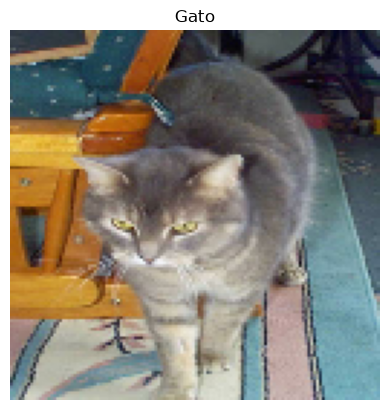

In [33]:
import matplotlib.pyplot as plt

plt.imshow(images[31].numpy())
plt.title("Gato" if labels[31].numpy() == 0 else "Cachorro")
plt.axis("off")
plt.show()

In [34]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3))
])

In [35]:
model.add(
    tf.keras.layers.Conv2D(16, (3, 3), activation="relu")
)

In [36]:
model.add(
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
)

In [37]:
model.add(tf.keras.layers.Flatten())

In [38]:
model.add(tf.keras.layers.Dense(32, activation="relu"))

In [39]:
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [40]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [57]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=2
)

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.7967 - loss: 0.4339 - val_accuracy: 0.7401 - val_loss: 0.5282
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 248ms/step - accuracy: 0.8291 - loss: 0.3764 - val_accuracy: 0.7293 - val_loss: 0.5766


In [58]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 63504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     2,032,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,097,925 (23.26 MB)

 Trainable params: 2,032,641 (7.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,065,284 (15.51 MB)

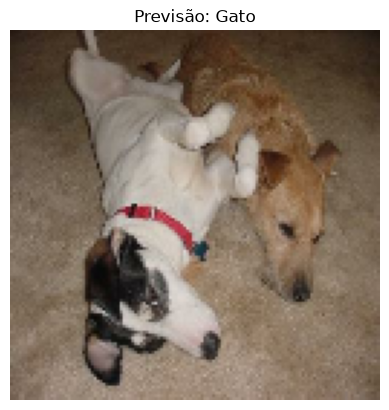

Rótulo real: Cachorro
Probabilidade estimada de cachorro: 5.5%


In [65]:
for images, labels in validation_dataset.take(1):
    image = images[0]
    true_label = int(labels[0].numpy())

probability = float(model.predict(image[None, ...], verbose=0)[0][0])
prediction = "Cachorro" if probability >= 0.5 else "Gato"

plt.imshow(image.numpy())
plt.title(f"Previsão: {prediction}")
plt.axis("off")
plt.show()

print("Rótulo real:", "Cachorro" if true_label == 1 else "Gato")
print(f"Probabilidade estimada de cachorro: {probability:.1%}")